In [5]:
import numpy as np
import pandas as pd
from zoneinfo import ZoneInfo
import matplotlib.pyplot as plt

In [6]:
def cfs_to_af(cfs_day):
    """
    Convert 'CFS‑days' to acre‑feet:

    acre‑ft = cfs_day / 1.9835
    """
    return cfs_day / 1.9835 


def af_to_m3(acft):
    """Convert acre‑feet to cubic metres (1 af = 1233.48 m³)."""
    return acft * 1233.48

def ft_to_m(ft):
    return ft / 3.281


## Load Storage Data

In [10]:
## Storage Data (Change in CFS/day)
BON_S = pd.read_excel("/Users/elizacohn/Desktop/Columbia River Data/BPA Data/daily/daily/BON6S_daily.xlsx")
TDA_S = pd.read_excel("/Users/elizacohn/Desktop/Columbia River Data/BPA Data/daily/daily/TDA6S_daily.xlsx")
JDA_S = pd.read_excel("/Users/elizacohn/Desktop/Columbia River Data/BPA Data/daily/daily/JDA6S_daily.xlsx")
MCN_S = pd.read_excel("/Users/elizacohn/Desktop/Columbia River Data/BPA Data/daily/daily/MCN6S_daily.xlsx")

BON_S["date"] = pd.to_datetime(BON_S["date"]).dt.normalize()
TDA_S["date"] = pd.to_datetime(TDA_S["date"]).dt.normalize()
JDA_S["date"] = pd.to_datetime(JDA_S["date"]).dt.normalize()
MCN_S["date"] = pd.to_datetime(MCN_S["date"]).dt.normalize()

In [11]:
## Calculate Relative Storage
BON_S["cumsumS"] = BON_S["S (unit:cfs)"].cumsum()
TDA_S["cumsumS"] = TDA_S["S (unit:cfs)"].cumsum()
JDA_S["cumsumS"] = JDA_S["S (unit:cfs)"].cumsum()
MCN_S["cumsumS"] = MCN_S["S (unit:cfs)"].cumsum()

# cfs‑days → acre‑feet → cubic metres
BON_S["S_m3"] = af_to_m3(cfs_to_af(BON_S["cumsumS"]))
TDA_S["S_m3"] = af_to_m3(cfs_to_af(TDA_S["cumsumS"]))
JDA_S["S_m3"] = af_to_m3(cfs_to_af(JDA_S["cumsumS"]))
MCN_S["S_m3"] = af_to_m3(cfs_to_af(MCN_S["cumsumS"]))

## Load Head Data

In [13]:
## Storage Data (Change in CFS/day)
BON_H = pd.read_csv("/Users/elizacohn/Desktop/Columbia River Data/US ACE Data 2026/bonneville-daily.csv")
TDA_H = pd.read_csv("/Users/elizacohn/Desktop/Columbia River Data/US ACE Data 2026/dalles-daily.csv")
JDA_H = pd.read_csv("/Users/elizacohn/Desktop/Columbia River Data/US ACE Data 2026/johnday-daily.csv")
MCN_H = pd.read_csv("/Users/elizacohn/Desktop/Columbia River Data/US ACE Data 2026/mcnary-daily.csv")

BON_H["Date Time"] = pd.to_datetime(BON_H["Date Time"])
TDA_H["Date Time"] = pd.to_datetime(TDA_H["Date Time"])
JDA_H["Date Time"] = pd.to_datetime(JDA_H["Date Time"])
MCN_H["Date Time"] = pd.to_datetime(MCN_H["Date Time"])

In [14]:
BON_daily = (BON_H.set_index("Date Time").resample("D").mean(numeric_only=True).reset_index())
TDA_daily = (TDA_H.set_index("Date Time").resample("D").mean(numeric_only=True).reset_index())
JDA_daily = (JDA_H.set_index("Date Time").resample("D").mean(numeric_only=True).reset_index())
MCN_daily = (MCN_H.set_index("Date Time").resample("D").mean(numeric_only=True).reset_index())

In [15]:
## Load special bonneville storage data
BON_S2 = pd.read_csv("/Users/elizacohn/Desktop/Columbia River Data/US ACE Data 2026/bonneville-storage.csv")
BON_S2["Date Time"] = pd.to_datetime(BON_S2["Date Time"])

# Fit Hydraulic Head

In [86]:
from sklearn.linear_model import HuberRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

def fit_head_huber(S, H, epsilon=1.35):
    mask = S.notna() & H.notna()
    x = S[mask].to_numpy().reshape(-1, 1)
    y = H[mask].to_numpy()

    model = HuberRegressor(epsilon=epsilon)
    model.fit(x, y)

    a = model.coef_[0]
    b = model.intercept_

    y_hat = model.predict(x)

    rmse = np.sqrt(mean_squared_error(y, y_hat))
    r2 = r2_score(y, y_hat)

    print(f"{a:.2f} {b:.2f}")
    print(f"RMSE: {rmse}")
    print(f"R2: {r2}")

    return a, b, model

### Merge Data

In [18]:
BON = (BON_daily.merge(BON_S2, left_on="Date Time", right_on="Date Time", how="inner").query("'2008-01-01' <= `Date Time` <= '2018-12-31'"))
TDA = (TDA_daily.merge(TDA_S, left_on="Date Time", right_on="date", how="inner").query("'2008-01-01' <= `Date Time` <= '2018-12-31'"))
JDA = (JDA_daily.merge(JDA_S, left_on="Date Time", right_on="date", how="inner").query("'2008-01-01' <= `Date Time` <= '2018-12-31'"))
MCN = (MCN_daily.merge(MCN_S, left_on="Date Time", right_on="date", how="inner").query("'2008-01-01' <= `Date Time` <= '2018-12-31'"))

In [19]:
def min_max(storage, forebay):
    min_V = storage.min()
    max_V = storage.max()
    min_H = forebay.min() 
    max_H = forebay.max()
    
    return min_V, max_V, min_H, max_H 


In [20]:
def fit_head(S, H):
    a, b = np.polyfit(S, H, 1)

    print(round(a,2), round(b,2))
    
    err = H - (a * S + b)
    rmse = np.sqrt(np.mean(err**2))
    r2 = 1 - np.sum(err**2) / np.sum((H - H.mean())**2)
    
    print("RMSE:", rmse)
    print("R2:", r2)
    return a, b

### Bonneville

In [88]:
min_V, max_V, min_H, max_H = min_max(BON["BON.Stor.Inst.1Hour.0.CBT-COMPUTED-REV [kaf]"], BON["BON.Elev-Forebay.Inst.1Hour.0.CBT-REV [ft]"])

BON["S_norm"] = (BON["BON.Stor.Inst.1Hour.0.CBT-COMPUTED-REV [kaf]"] - min_V) / (max_V - min_V)
BON["H_norm"] = (BON["BON.Elev-Forebay.Inst.1Hour.0.CBT-REV [ft]"] - min_H) / (max_H - min_H)

In [90]:
a, b, model = fit_head_huber(BON["S_norm"], BON["H_norm"])

0.89 0.06
RMSE: 0.0697904920572908
R2: 0.7950814497420433


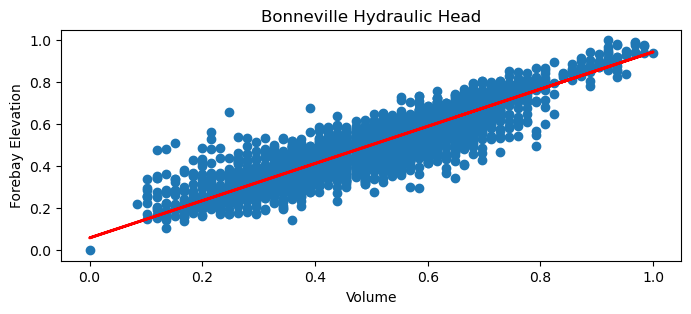

In [94]:
x = BON["S_norm"]
y_fit = a * x + b

plt.figure(figsize=(8, 3))
plt.scatter(BON["S_norm"], BON["H_norm"])
plt.plot(x, y_fit, color="red", linewidth=2, label="Best fit")

plt.ylabel("Forebay Elevation")
plt.xlabel("Volume")
plt.title("Bonneville Hydraulic Head")
plt.show()

### Dalles Dam

In [68]:
min_V, max_V, min_H, max_H = min_max(TDA["S_m3"], TDA["TDA.Elev-Forebay.Inst.1Hour.0.CBT-REV [ft]"])

TDA["S_norm"] = (TDA["S_m3"] - min_V) / (max_V - min_V)
TDA["H_norm"] = (TDA["TDA.Elev-Forebay.Inst.1Hour.0.CBT-REV [ft]"] - min_H) / (max_H - min_H)

In [96]:
a, b, model = fit_head_huber(TDA["S_norm"], TDA["H_norm"])

0.71 0.23
RMSE: 0.08246848105206618
R2: 0.47989044690341753


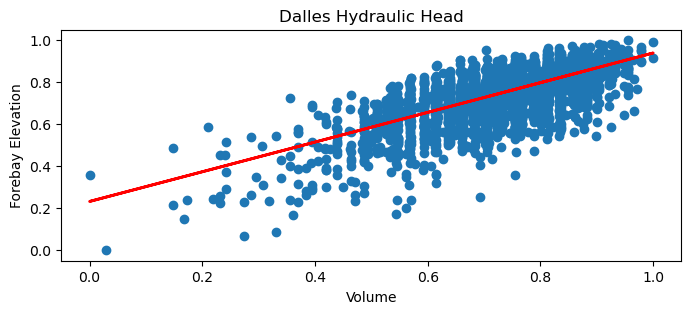

In [98]:
x = TDA["S_norm"]
y_fit = a * x + b

plt.figure(figsize=(8, 3))
plt.scatter(TDA["S_norm"], TDA["H_norm"])
plt.plot(x, y_fit, color="red", linewidth=2, label="Best fit")
plt.ylabel("Forebay Elevation")
plt.xlabel("Volume")
plt.title("Dalles Hydraulic Head")
plt.show()

### John Day Dam

In [74]:
min_V, max_V, min_H, max_H = min_max(JDA["S_m3"], JDA["JDA.Elev-Forebay.Inst.1Hour.0.CBT-REV [ft]"])

JDA["S_norm"] = (JDA["S_m3"] - min_V) / (max_V - min_V)
JDA["H_norm"] = (JDA["JDA.Elev-Forebay.Inst.1Hour.0.CBT-REV [ft]"] - min_H) / (max_H - min_H)

In [100]:
a, b, model = fit_head_huber(JDA["S_norm"], JDA["H_norm"])

0.90 0.08
RMSE: 0.04040354041514798
R2: 0.7996864093477016


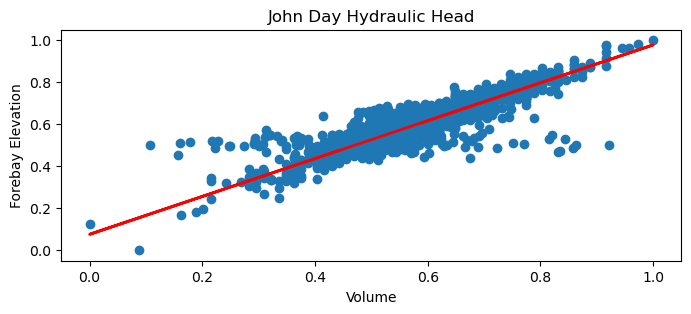

In [102]:
x = JDA["S_norm"]
y_fit = a * x + b

plt.figure(figsize=(8, 3))
plt.scatter(JDA["S_norm"], JDA["H_norm"])
plt.plot(x, y_fit, color="red", linewidth=2, label="Best fit")
plt.ylabel("Forebay Elevation")
plt.xlabel("Volume")
plt.title("John Day Hydraulic Head")
plt.show()

### McNary

In [80]:
min_V, max_V, min_H, max_H = min_max(MCN["S_m3"], MCN["MCN.Elev-Forebay.Inst.1Hour.0.CBT-REV [ft]"])

MCN["S_norm"] = (MCN["S_m3"] - min_V) / (max_V - min_V)
MCN["H_norm"] = (MCN["MCN.Elev-Forebay.Inst.1Hour.0.CBT-REV [ft]"] - min_H) / (max_H - min_H)

In [108]:
a, b = fit_head(MCN["S_norm"], MCN["H_norm"])

1.44 -0.37
RMSE: 0.11044524684218059
R2: 0.45358847354488363


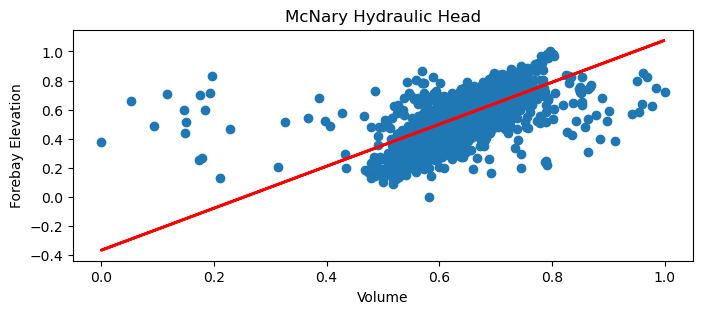

In [110]:
x = MCN["S_norm"]
y_fit = a * x + b

plt.figure(figsize=(8, 3))

plt.plot(x, y_fit, color="red", linewidth=2, label="Best fit")
plt.scatter(MCN["S_norm"], MCN["H_norm"])
plt.ylabel("Forebay Elevation")
plt.xlabel("Volume")
plt.title("McNary Hydraulic Head")
plt.show()